# Description of notebook

This notebook consists of feature exploration tasks carried out for the hourly-aggregated and summary datasets. 
The tasks include the following, and cells are labelled with comments: 
--Reviewing data types
--Reviewing summary statistics
--Reviewing correlation coefficients
--Obtaining proportion of pairs that were highly correlated
--Producing correlation heatmaps
--Reviewing skewness
--Generating histograms for selected variables
--Reviewing missing values

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
import getpass
from sqlalchemy import create_engine, text
import os
from dotenv import load_dotenv
from matplotlib import pyplot

In [28]:
PROJECT_ROOT = Path.cwd().parents[0]   # adjust after checking Path.cwd()
TABLES_DIR = PROJECT_ROOT / 'results' / 'tables'
PLOTS_DIR = PROJECT_ROOT / 'results' / 'plots'
load_dotenv()
BACKUP_ROOT = Path(os.environ["BACKUP_ROOT"])
DATA_DIR = BACKUP_ROOT / 'results' / 'data'
REPRESENTATIVE_VARS = ['heart_rate', 'sbp', 'dbp', 'resp_rate', 'spo2', 'glucose_vital', 'gcs', 'creatinine', 'potassium', 'wbc']

In [5]:
pg_user = 'postgres'      # same value you use to connect via psql
pg_host = 'localhost'          # or wherever your Postgres server is
pg_port = 5432
pg_dbname = 'mimiciv'

pg_password = getpass.getpass('Postgres password: ')

engine = create_engine(
    f'postgresql+psycopg2://{pg_user}:{pg_password}@{pg_host}:{pg_port}/{pg_dbname}'
)


In [ ]:
# Restrict to Train dataset

Ys_train = pd.read_parquet(DATA_DIR / 'Ys_train.parquet', engine='pyarrow')
train_ids = sorted(set(Ys_train.index.get_level_values('icustay_id')))
n_train = len(train_ids)
print(n_train)

36286


In [8]:
# Read in the hourly aggregated dataset

hourly_ds = pd.read_sql(text("SELECT * FROM msc_project.hourly_data WHERE icustay_id = ANY(:ids)"), engine, params = {'ids': train_ids})

hourly_id_cols = ['subject_id', 'hadm_id', 'icustay_id', 'hours_in', 'hour_end']
hourly_vars = [c for c in hourly_ds.columns if c not in hourly_id_cols]

In [9]:
# Read in the summary representation dataset

summary_ds = pd.read_sql(text("SELECT * FROM msc_project.alternative_data WHERE icustay_id = ANY(:ids)"), engine, params = {'ids': train_ids})

summary_ds.head()

,subject_id,hadm_id,icustay_id,variable_name,value_min,value_max,value_avg,value_std,value_count,value_first,value_last,value_first_time,value_last_time,value_slope
0,12466550,23998182,30000153,aniongap,12.0,12.0,12.0,0.000000,2,12.0,12.0,3.466667,15.416667,0.000000
1,12466550,23998182,30000153,bicarbonate,19.0,23.0,21.0,2.828427,2,19.0,23.0,3.466667,15.416667,0.334728
2,12466550,23998182,30000153,bun,22.0,22.0,22.0,0.000000,2,22.0,22.0,3.466667,15.416667,0.000000
3,12466550,23998182,30000153,calcium,7.4,8.0,7.7,0.424264,2,7.4,8.0,3.466667,15.416667,0.050209
4,12466550,23998182,30000153,chloride,115.0,115.0,115.0,0.000000,2,115.0,115.0,3.466667,15.416667,0.000000


In [10]:
# Pivot summary representation dataset to wide

summary_flat_mean = summary_ds.pivot_table(index='icustay_id', columns='variable_name', values= 'value_avg')

summary_flat_mean.head()
summary_flat_mean.shape

(36285, 30)

In [ ]:
# data types - hourly representation

types_hourly = hourly_ds.dtypes
print(types_hourly)
# all float64

subject_id                int64
hadm_id                   int64
icustay_id                int64
hours_in                  int64
hour_end         datetime64[us]
heart_rate              float64
sbp                     float64
dbp                     float64
mbp                     float64
resp_rate               float64
temperature             float64
spo2                    float64
glucose_vital           float64
albumin                 float64
globulin                float64
total_protein           float64
aniongap                float64
bicarbonate             float64
bun                     float64
calcium                 float64
chloride                float64
creatinine              float64
sodium                  float64
potassium               float64
magnesium               float64
gcs                     float64
hematocrit              float64
hemoglobin              float64
mch                     float64
mchc                    float64
mcv                     float64
platelet

In [ ]:
# data types - summary representation

types_summary = summary_flat_mean.dtypes
print(types_summary)

variable_name
albumin          float64
aniongap         float64
bicarbonate      float64
bun              float64
calcium          float64
chloride         float64
creatinine       float64
dbp              float64
gcs              float64
globulin         float64
glucose_vital    float64
heart_rate       float64
hematocrit       float64
hemoglobin       float64
magnesium        float64
mbp              float64
mch              float64
mchc             float64
mcv              float64
platelet         float64
potassium        float64
rbc              float64
rdw              float64
resp_rate        float64
sbp              float64
sodium           float64
spo2             float64
temperature      float64
total_protein    float64
wbc              float64
dtype: object


In [ ]:
#  summary statistics - hourly representation

description_hourly = hourly_ds[hourly_vars].describe()
print(description_hourly)
description_hourly.to_csv(TABLES_DIR / 'description_hourly.csv')

          heart_rate            sbp            dbp            mbp  \
count  829373.000000  313620.000000  313562.000000  315404.000000   
mean       84.349974     116.310797      58.501207      77.675702   
std        18.195185      19.386800      11.711822      14.497597   
min        12.000000       4.000000       1.000000       1.000000   
25%        71.000000     103.000000      51.000000      69.000000   
50%        83.000000     114.000000      57.000000      76.000000   
75%        95.500000     127.500000      65.000000      84.500000   
max       280.000000     357.000000     293.000000     299.000000   

           resp_rate    temperature           spo2  glucose_vital  \
count  821209.000000  280169.000000  803032.000000  242944.000000   
mean       19.213143      36.900336      96.810965     146.565951   
std         5.352315       0.700857       2.881036      62.928529   
min         1.000000      22.000000       4.000000       0.120000   
25%        15.750000      36.5600

In [ ]:
# summary statistics - summary representation

description_summary = summary_flat_mean.describe()
print(description_summary)
description_summary.to_csv(TABLES_DIR / 'description_summary.csv')

variable_name       albumin      aniongap   bicarbonate           bun  \
count          13026.000000  35850.000000  35885.000000  35893.000000   
mean               3.279094     13.847976     23.076037     24.267048   
std                0.698637      3.582490      3.986211     20.087562   
min                0.600000      2.000000      4.000000      1.000000   
25%                2.800000     11.500000     21.000000     12.500000   
50%                3.300000     13.500000     23.000000     17.750000   
75%                3.800000     15.666667     25.000000     28.000000   
max                5.500000     45.750000     49.000000    228.000000   

variable_name       calcium      chloride    creatinine           dbp  \
count          33137.000000  35896.000000  35893.000000  16644.000000   
mean               8.406787    104.144738      1.331723     59.279124   
std                0.737247      5.800176      1.419952      9.401591   
min                4.225000     67.500000      0.1

In [ ]:
# Correlation coefficients - hourly representation

corrs_hourly = hourly_ds[hourly_vars].corr(method='pearson')
print(corrs_hourly)

               heart_rate       sbp       dbp       mbp  resp_rate  \
heart_rate       1.000000 -0.078634  0.186194  0.064720   0.290533   
sbp             -0.078634  1.000000  0.443017  0.718699  -0.020065   
dbp              0.186194  0.443017  1.000000  0.850687   0.042081   
mbp              0.064720  0.718699  0.850687  1.000000   0.011492   
resp_rate        0.290533 -0.020065  0.042081  0.011492   1.000000   
temperature      0.242261 -0.002332 -0.029555 -0.048057   0.142924   
spo2            -0.110099  0.045371  0.043339  0.053557  -0.163473   
glucose_vital    0.103347  0.034918  0.067428  0.070462   0.102515   
albumin         -0.179344  0.212399  0.144887  0.188935  -0.108618   
globulin        -0.030702  0.239587 -0.033078  0.205904   0.047061   
total_protein   -0.116472  0.248870  0.176338  0.332828  -0.033634   
aniongap         0.177429 -0.030525  0.027919  0.015009   0.208509   
bicarbonate     -0.126922  0.113515  0.011979  0.041021  -0.129834   
bun              0.0

In [ ]:
# Correlation coefficients - summary representation

corrs_summary = summary_flat_mean.corr(method='pearson')
print(corrs_summary)

variable_name   albumin  aniongap  bicarbonate       bun   calcium  chloride  \
variable_name                                                                  
albumin        1.000000  0.007187     0.187373 -0.168569  0.466171 -0.082041   
aniongap       0.007187  1.000000    -0.438445  0.427935  0.053167 -0.284957   
bicarbonate    0.187373 -0.438445     1.000000 -0.206143  0.254081 -0.287716   
bun           -0.168569  0.427935    -0.206143  1.000000 -0.001986 -0.114133   
calcium        0.466171  0.053167     0.254081 -0.001986  1.000000 -0.179078   
chloride      -0.082041 -0.284957    -0.287716 -0.114133 -0.179078  1.000000   
creatinine    -0.080151  0.452267    -0.207838  0.668698 -0.016134 -0.185268   
dbp            0.047580  0.026955     0.034278 -0.175903  0.045365  0.029243   
gcs           -0.000156 -0.055506     0.011107 -0.066467 -0.048009 -0.054679   
globulin      -0.110004 -0.008107     0.068085  0.057434  0.165200 -0.178595   
glucose_vital -0.067680  0.194361    -0.

In [27]:
# Get proportion of pairs that are highly correlated


def high_corr(corrs_matrix, threshold):
    high_pairs = []
    variables = corrs_matrix.columns.tolist()
    for i in range(len(variables)):
        for j in range(i + 1, len(variables)):
            var1 = variables[i]
            var2 = variables[j]
            c = corrs_matrix.loc[var1, var2]
            if c > threshold:
                high_pairs.append((var1, var2, c))
    pairs_total = len(variables) * (len(variables) - 1) / 2
    pct_high = len(high_pairs) / pairs_total * 100
    print(f'{pct_high:.2f}% are highly correlated (>{threshold})')
    for var1, var2, c in high_pairs:
        print(f'{var1}, {var2}, {c:.2f}')


high_corr(corrs_hourly, 0.8)
high_corr(corrs_summary, 0.8)


1.15% are highly correlated (>0.8)
dbp, mbp, 0.85
hematocrit, hemoglobin, 0.97
hematocrit, rbc, 0.93
hemoglobin, rbc, 0.91
mch, mcv, 0.83
1.15% are highly correlated (>0.8)
dbp, mbp, 0.82
hematocrit, hemoglobin, 0.96
hematocrit, rbc, 0.92
hemoglobin, rbc, 0.89
mch, mcv, 0.84


In [36]:
# sort variable order for the correlation matrices

variable_order = sorted(corrs_hourly.columns)

corrs_hourly_ordered = corrs_hourly.loc[variable_order, variable_order]
corrs_summary_ordered = corrs_summary.loc[variable_order, variable_order]

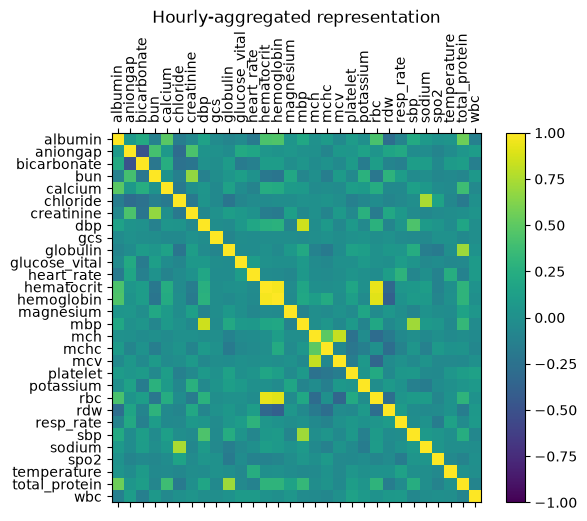

In [41]:
# correlation matrix - hourly representation

hourly_fig = pyplot.figure()
ax = hourly_fig.add_subplot(111)
cax = ax.matshow(corrs_hourly_ordered, vmin=-1, vmax = 1)
hourly_fig.colorbar(cax)
ticks = np.arange(len(corrs_hourly_ordered.columns))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(corrs_hourly_ordered.columns, rotation=90)
ax.set_yticklabels(corrs_hourly_ordered.columns)
ax.set_title('Hourly-aggregated representation')
hourly_fig.savefig(PLOTS_DIR / 'correlation_hourly.png', bbox_inches='tight', dpi=300)
pyplot.show()


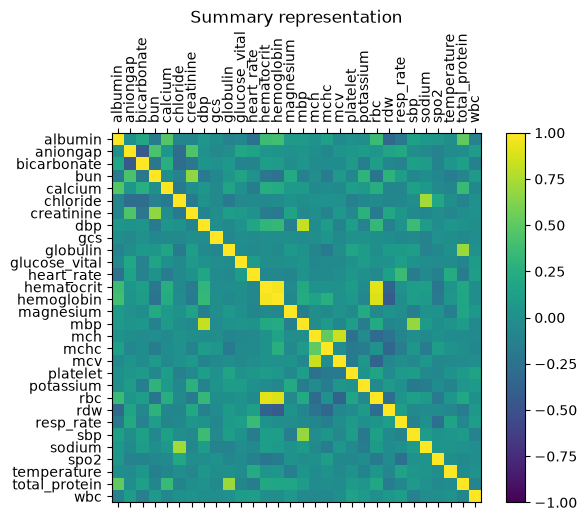

In [44]:
# correlation matrix - summary representation

summary_fig = pyplot.figure()
ax = summary_fig.add_subplot(111)
cax = ax.matshow(corrs_summary_ordered, vmin=-1, vmax = 1)
summary_fig.colorbar(cax)
ticks = np.arange(len(corrs_summary_ordered.columns))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(corrs_summary_ordered.columns, rotation=90)
ax.set_yticklabels(corrs_summary_ordered.columns)
ax.set_title('Summary representation')
summary_fig.savefig(PLOTS_DIR / 'correlation_summary.png', bbox_inches='tight', dpi=300)
pyplot.show()

In [ ]:
# skew - hourly representation

skew_hourly = hourly_ds[hourly_vars].skew()
print(skew_hourly)
skew_hourly.to_csv(TABLES_DIR / 'skew_hourly.csv')

heart_rate        0.528652
sbp               0.666194
dbp               1.088089
mbp               2.512486
resp_rate         0.866821
temperature      -0.401167
spo2             -2.715422
glucose_vital     3.342854
albumin          -0.081571
globulin          2.220470
total_protein     1.788915
aniongap          1.348399
bicarbonate       0.007904
bun               2.460974
calcium           0.806203
chloride         -0.253702
creatinine        5.104635
sodium           -0.230508
potassium         1.498929
magnesium         4.921045
gcs              -4.166523
hematocrit        0.369833
hemoglobin        0.305950
mch              -0.394495
mchc             -0.062860
mcv               0.173849
platelet          2.241599
rbc               0.323948
rdw               1.760097
wbc              12.953939
dtype: float64


In [ ]:
# skew - summary representation

skew_summary = summary_flat_mean.skew()
print(skew_summary)
skew_summary.to_csv(TABLES_DIR / 'skew_summary.csv')

variable_name
albumin          -0.135932
aniongap          1.163958
bicarbonate       0.262197
bun               2.725576
calcium           0.533254
chloride         -0.387409
creatinine        5.661512
dbp               0.709997
gcs              -3.712271
globulin          2.333380
glucose_vital     2.219646
heart_rate        0.481263
hematocrit        0.329658
hemoglobin        0.275695
magnesium         2.602662
mbp               2.846944
mch              -0.466796
mchc             -0.240904
mcv               0.063670
platelet          2.185891
potassium         0.859153
rbc               0.316940
rdw               1.835043
resp_rate         1.002898
sbp               0.917619
sodium           -0.312744
spo2             -1.689979
temperature      -0.775235
total_protein     1.509653
wbc              13.411606
dtype: float64


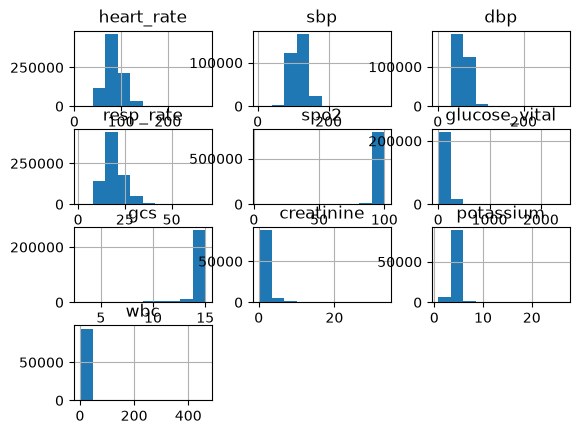

In [ ]:
# histograms for selected variables - hourly representation

hourly_ds[REPRESENTATIVE_VARS].hist()
pyplot.show()
# need to adjust the appearance

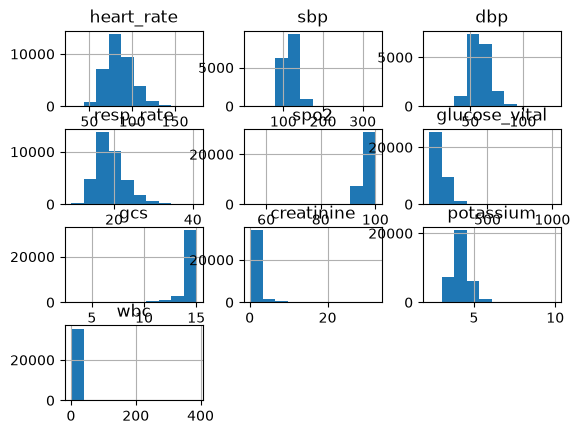

In [ ]:
# histograms for selected variables - summary representation

summary_flat_mean[REPRESENTATIVE_VARS].hist()
pyplot.show()
# need to adjust the appearance

In [ ]:
# missing data - hourly representation

n_missing_hourly = hourly_ds[hourly_vars].isna().sum()
print(n_missing_hourly)
n_missing_hourly.to_csv(TABLES_DIR / 'n_missing_hourly.csv')

heart_rate        948641
sbp              1464394
dbp              1464452
mbp              1462610
resp_rate         956805
temperature      1497845
spo2              974982
glucose_vital    1535070
albumin          1760428
globulin         1777459
total_protein    1777021
aniongap         1685715
bicarbonate      1684821
bun              1684140
calcium          1700510
chloride         1681009
creatinine       1683847
sodium           1682867
potassium        1680681
magnesium        1694489
gcs              1486572
hematocrit       1668739
hemoglobin       1681869
mch              1683357
mchc             1683331
mcv              1683326
platelet         1681172
rbc              1683325
rdw              1683405
wbc              1683220
dtype: int64


In [ ]:
# missing data - summary representation

n_missing_summary = summary_flat_mean.isna().sum()
print(n_missing_summary)
n_missing_summary.to_csv(TABLES_DIR / 'n_missing_summary.csv')

variable_name
albumin          23259
aniongap           435
bicarbonate        400
bun                392
calcium           3148
chloride           389
creatinine         392
dbp              19641
gcs                 60
globulin         35755
glucose_vital      211
heart_rate          49
hematocrit         462
hemoglobin         518
magnesium         1493
mbp              19582
mch                523
mchc               523
mcv                514
platelet           502
potassium          414
rbc                514
rdw                528
resp_rate          106
sbp              19644
sodium             395
spo2                58
temperature       1130
total_protein    35342
wbc                514
dtype: int64
